In [1]:
# Import graph and memory components
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_mistralai import ChatMistralAI
# Import utilities to trim messages and count tokens
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [2]:
# Load environment variables
load_dotenv()

True

In [3]:
# Initialize the Mistral model
model = ChatMistralAI(model="mistral-small-2506")

In [4]:
# Define the maximum number of tokens we want to keep in memory
# This prevents the context from exceeding the LLM's token limit or saving cost
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    # Trim conversation history to keep only the last N messages that fit within the token budget
    # strategy="last" means we keep the most recent messages.
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    # Log the current token count for debugging
    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    # Pass only the trimmed messages to the model
    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
# Compile with memory to track the conversation
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

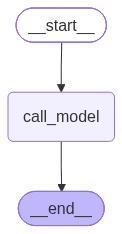

In [8]:
# View the compiled graph
graph

In [9]:
# Start a conversation on 'chat-1'
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Archit."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Archit.


"Hi Archit! It's nice to meet you. How can I assist you today?"

In [10]:
# Add more messages. Trimming will happen automatically in the 'call_model' node.
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 41
Hi, my name is Archit.
Hi Archit! It's nice to meet you. How can I assist you today?
I am learning LangGraph.


'That’s great! **LangGraph** is a powerful framework for building stateful, multi-actor applications with LLMs (Large Language Models) at their core. It’s built on top of **LangChain** and provides a more structured way to handle complex workflows, including multi-agent systems, tool usage, and memory management.\n\n### **Key Concepts in LangGraph:**\n1. **Graphs** – Workflows are defined as graphs (nodes = steps, edges = transitions).\n2. **Nodes** – Represent functions or tools (e.g., LLMs, APIs, custom logic).\n3. **Edges** – Define the flow between nodes (conditional, sequential, or dynamic).\n4. **State** – A shared memory object that passes data between nodes.\n5. **Tools** – Functions that agents can call (e.g., web searches, code execution).\n\n### **Example: Simple LangGraph Workflow**\nHere’s a basic example where an LLM decides whether to use a tool or respond directly:\n\n```python\nfrom langgraph.graph import Graph\nfrom langgraph.prebuilt import ToolNode\nfrom langchain_c

In [11]:
# Continue adding context
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a crucial part of how we process and store information temporarily. It allows us to hold and manipulate a small amount of information in our minds for brief periods, typically ranging from a few seconds to a minute. Here’s a breakdown of its key aspects:\n\n### **1. Definition and Duration**\n- **Duration:** Information in STM lasts for about **15–30 seconds** unless actively maintained (rehearsed).\n- **Capacity:** The "magic number" is **7 ± 2** items (George Miller, 1956), though some research suggests it may be closer to **4 ± 1** items in practice (Cowan, 2001).\n- **Forgetting:** Information fades quickly due to **decay** (passive fading) or **interference** (new information displacing old).\n\n### **2. How It Works**\nSTM is often compared to a **mental workspace** where information is:\n- **Encoded** (processed into a form the brain can use).\n- **Stored** (held temporarily).\n- **Retrieved** (accessed when needed).\n\n### **3. Components of STM (Bad

In [12]:
# As the conversation grows, older messages are trimmed.
# The model might forget the name if the initial message was trimmed out of the 150 token budget.
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have access to personal information about you unless you’ve shared it with me in our conversation. If you’d like to tell me your name, I’d be happy to remember it for this chat! 😊\n\n(If you’re referring to a different context, let me know—I’m happy to help!)'

In [13]:
# We can view the actual state to see all messages
# Note: The state contains ALL messages. Trimming only happens when passing them to the LLM.
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Archit.
------------------------------------------------------------------------------------------------------------------------
Hi Archit! It's nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! **LangGraph** is a powerful framework for building stateful, multi-actor applications with LLMs (Large Language Models) at their core. It’s built on top of **LangChain** and provides a more structured way to handle complex workflows, including multi-agent systems, tool usage, and memory management.

### **Key Concepts in LangGraph:**
1. **Graphs** – Workflows are defined as graphs (nodes = steps, edges = transitions).
2. **Nodes** – Represent functions or tools (e.g., LLMs, APIs, custom logic).
3. **Edges** 